## 1) Environment Setup & Execution Toggle

In [2]:
!ls /kaggle/input

datasets


In [3]:
!ls /kaggle/input/*

senomynearl


In [4]:
# =========================
# MASTER CONFIGURATION CELL
# =========================
EXECUTION_ENV = 'kaggle'  # 'local' or 'kaggle'

import os
from pathlib import Path

if EXECUTION_ENV.lower() == 'kaggle':
    NUM_GPUS = 2
    BASE_DIR = Path('/kaggle/working')
    RAW_IMAGE_ROOT = Path('/kaggle/input/datasets/senomynearl/dentaldasatetsready-512/DentalDatasetsReady_512')
    RAW_MASK_ROOT = Path('/kaggle/input/datasets/senomynearl/dentaldatasetready-512-mask/DentalDatasetsReady_512_mask')
else:
    NUM_GPUS = 1
    BASE_DIR = Path(r'd:/Semester_4/DL/w7/nnunet_dental')
    RAW_IMAGE_ROOT = Path(r'd:/Semester_4/DL/w7/DentalDatasetsReady_512')
    RAW_MASK_ROOT = Path(r'd:/Semester_4/DL/w7/DentalDatasetsReady_512_mask')

DATASET_ID = 501
DATASET_NAME = f'Dataset{DATASET_ID:03d}_Dental'

NNUNET_RAW = BASE_DIR / 'nnUNet_raw'
NNUNET_PREPROCESSED = BASE_DIR / 'nnUNet_preprocessed'
NNUNET_RESULTS = BASE_DIR / 'nnUNet_results'

os.environ['nnUNet_raw'] = str(NNUNET_RAW)
os.environ['nnUNet_preprocessed'] = str(NNUNET_PREPROCESSED)
os.environ['nnUNet_results'] = str(NNUNET_RESULTS)

for p in [NNUNET_RAW, NNUNET_PREPROCESSED, NNUNET_RESULTS, BASE_DIR / 'outputs', BASE_DIR / 'reports']:
    p.mkdir(parents=True, exist_ok=True)

DATASET_DIR = NNUNET_RAW / DATASET_NAME
IMAGES_TR = DATASET_DIR / 'imagesTr'
LABELS_TR = DATASET_DIR / 'labelsTr'
IMAGES_TS = DATASET_DIR / 'imagesTs'

for p in [DATASET_DIR, IMAGES_TR, LABELS_TR, IMAGES_TS]:
    p.mkdir(parents=True, exist_ok=True)

print(f'Execution env: {EXECUTION_ENV}')
print(f'NUM_GPUS: {NUM_GPUS}')
print(f'nnUNet_raw: {os.environ["nnUNet_raw"]}')
print(f'nnUNet_preprocessed: {os.environ["nnUNet_preprocessed"]}')
print(f'nnUNet_results: {os.environ["nnUNet_results"]}')

Execution env: kaggle
NUM_GPUS: 2
nnUNet_raw: /kaggle/working/nnUNet_raw
nnUNet_preprocessed: /kaggle/working/nnUNet_preprocessed
nnUNet_results: /kaggle/working/nnUNet_results


In [5]:
# Optional dependency bootstrap (run once per environment)
# You can uncomment if packages are not installed.
!pip install -q nnunetv2 opencv-python scikit-image pandas matplotlib tqdm monai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 205.6/205.6 kB 11.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 5.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 47.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.7/73.7 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.5/26.5 MB 74.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 89.1

## 2) Data Ingestion & Auto-Renaming (`Dataset501_Dental`)

In [6]:
import json
import shutil
import cv2
import numpy as np
from collections import defaultdict
from tqdm import tqdm

def list_by_stem(folder: Path):
    exts = {'.png', '.jpg', '.jpeg', '.tif', '.tiff', '.bmp'}
    files = [p for p in folder.glob('*') if p.suffix.lower() in exts and p.is_file()]
    return {p.stem: p for p in files}

def to_png(src: Path, dst: Path, is_mask: bool = False):
    # Force OpenCV to read the image as 1-channel Grayscale
    img = cv2.imread(str(src), cv2.IMREAD_GRAYSCALE) 
    
    if img is None:
        raise ValueError(f'Failed reading: {src}')

    if is_mask:
        img = (img > 0).astype(np.uint8)

    ok = cv2.imwrite(str(dst), img)
    if not ok:
        raise ValueError(f'Failed writing: {dst}')
        
# def to_png(src: Path, dst: Path, is_mask: bool = False):
#     img = cv2.imread(str(src), cv2.IMREAD_UNCHANGED)
#     if img is None:
#         raise ValueError(f'Failed reading: {src}')

#     if is_mask:
#         if img.ndim == 3:
#             img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
#         img = (img > 0).astype(np.uint8)

#     ok = cv2.imwrite(str(dst), img)
#     if not ok:
#         raise ValueError(f'Failed writing: {dst}')

for p in [IMAGES_TR, LABELS_TR, IMAGES_TS]:
    for f in p.glob('*'):
        if f.is_file():
            f.unlink()

mapping = {}
split_stats = defaultdict(int)
case_counter = 1

for split in ['train', 'valid', 'test']:
    img_split_dir = RAW_IMAGE_ROOT / split
    msk_split_dir = RAW_MASK_ROOT / split

    if not img_split_dir.exists() or not msk_split_dir.exists():
        raise FileNotFoundError(f'Missing split dirs for {split}: {img_split_dir} | {msk_split_dir}')

    img_by_stem = list_by_stem(img_split_dir)
    msk_by_stem = list_by_stem(msk_split_dir)

    common_stems = sorted(set(img_by_stem.keys()) & set(msk_by_stem.keys()))
    missing_masks = sorted(set(img_by_stem.keys()) - set(msk_by_stem.keys()))
    missing_images = sorted(set(msk_by_stem.keys()) - set(img_by_stem.keys()))

    if missing_masks:
        print(f'[{split}] WARNING: {len(missing_masks)} images without mask')
    if missing_images:
        print(f'[{split}] WARNING: {len(missing_images)} masks without image')

    for stem in tqdm(common_stems, desc=f'Processing {split}'):
        src_img = img_by_stem[stem]
        src_msk = msk_by_stem[stem]

        case_id = f'case_{case_counter:05d}'
        tr_img_name = f'{case_id}_0000.png'
        tr_lbl_name = f'{case_id}.png'

        if split in ('train', 'valid'):
            dst_img = IMAGES_TR / tr_img_name
            dst_lbl = LABELS_TR / tr_lbl_name
            to_png(src_img, dst_img, is_mask=False)
            to_png(src_msk, dst_lbl, is_mask=True)
        else:
            dst_img = IMAGES_TS / tr_img_name
            to_png(src_img, dst_img, is_mask=False)

        mapping[case_id] = {
            'split': split,
            'original_image_filename': src_img.name,
            'original_mask_filename': src_msk.name,
            'original_image_path': str(src_img),
            'original_mask_path': str(src_msk),
            'nnunet_image': str(dst_img.name),
            'nnunet_label': tr_lbl_name if split in ('train', 'valid') else None
        }
        split_stats[split] += 1
        case_counter += 1

mapping_path = DATASET_DIR / 'filename_mapping.json'
with open(mapping_path, 'w', encoding='utf-8') as f:
    json.dump(mapping, f, indent=2)


dataset_json = {
    'channel_names': {'0': 'grayscale'},
    'labels': {'background': 0, 'tooth': 1},
    'numTraining': split_stats['train'] + split_stats['valid'],
    'file_ending': '.png'
}


# dataset_json = {
#     'channel_names': {'0': 'RGB'},
#     'labels': {'background': 0, 'tooth': 1},
#     'numTraining': split_stats['train'] + split_stats['valid'],
#     'file_ending': '.png'
# }

dataset_json_path = DATASET_DIR / 'dataset.json'
with open(dataset_json_path, 'w', encoding='utf-8') as f:
    json.dump(dataset_json, f, indent=2)

print('Dataset conversion complete')
print('Split stats:', dict(split_stats))
print('Mapping saved to:', mapping_path)
print('dataset.json saved to:', dataset_json_path)

Processing test: 100%|██████████| 1345/1345 [00:13<00:00, 96.98it/s]

Dataset conversion complete
Split stats: {'train': 4772, 'valid': 2071, 'test': 1345}
Mapping saved to: /kaggle/working/nnUNet_raw/Dataset501_Dental/filename_mapping.json
dataset.json saved to: /kaggle/working/nnUNet_raw/Dataset501_Dental/dataset.json


In [7]:
# Plan and preprocess
!nnUNetv2_plan_and_preprocess -d {DATASET_ID} --verify_dataset_integrity

Fingerprint extraction...
Dataset501_Dental
Using <class 'nnunetv2.imageio.natural_image_reader_writer.NaturalImage2DIO'> as reader/writer

####################
verify_dataset_integrity Done. 
If you didn't see any error messages then your dataset is most likely OK!
####################

Using <class 'nnunetv2.imageio.natural_image_reader_writer.NaturalImage2DIO'> as reader/writer
Extracting dataset fingerprint: 100%|██████| 6843/6843 [00:40<00:00, 167.87it/s]
Experiment planning...

############################
INFO: You are using the old nnU-Net default planner. We have updated our recommendations. Please consider using those instead! Read more here: https://github.com/MIC-DKFZ/nnUNet/blob/master/documentation/resenc_presets.md
############################

2D U-Net configuration:
{'data_identifier': 'nnUNetPlans_2d', 'preprocessor_name': 'DefaultPreprocessor', 'batch_size': 12, 'patch_size': (np.int64(512), np.int64(512)), 'median_image_size_in_voxels': array([512., 512.]), 'spacing

## 3) Scenario 1: Baseline Inference & Bounding Box Extraction

In [8]:
# Configure scenario output folders
SCENARIO1_OUT = BASE_DIR / 'outputs' / 'scenario1_baseline'
SCENARIO1_PRED = SCENARIO1_OUT / 'pred_masks'
SCENARIO1_BBOX_JSON = SCENARIO1_OUT / 'bboxes.json'
SCENARIO1_VIS = SCENARIO1_OUT / 'visualizations'
for p in [SCENARIO1_OUT, SCENARIO1_PRED, SCENARIO1_VIS]:
    p.mkdir(parents=True, exist_ok=True)

In [53]:
import os
import shutil

# 1. Define the missing Scenario 1 directory
scenario_1_dir = '/kaggle/working/nnUNet_results/Dataset501_Dental/nnUNetTrainer__nnUNetPlans__2d'

# 2. Force create the directory path if it doesn't exist
os.makedirs(scenario_1_dir, exist_ok=True)

# 3. Define the path to the dataset.json YOUR script generated
source_json_path = '/kaggle/working/nnUNet_raw/Dataset501_Dental/dataset.json' 

# 4. Copy the file over to pacify the predictor
target_json_path = os.path.join(scenario_1_dir, 'dataset.json')

try:
    shutil.copy(source_json_path, target_json_path)
    print(f"Success! dataset.json forcefully copied to:\n{target_json_path}")
except FileNotFoundError:
    print(f"Error: Could not find the source JSON at {source_json_path}.")

Success! dataset.json forcefully copied to:
/kaggle/working/nnUNet_results/Dataset501_Dental/nnUNetTrainer__nnUNetPlans__2d/dataset.json


In [55]:
# Baseline inference using available/baseline nnU-Net weights.
# Ensure baseline model exists under nnUNet_results for dataset 501.
# 1. First, train the baseline for 5 epochs on Fold 0 to generate the plans and weights
!nnUNetv2_train {DATASET_ID} 2d 0 -tr nnUNetTrainer_5epochs

# 2. Then, run the prediction explicitly targeting the checkpoint generated by that specific trainer
!nnUNetv2_predict -i {IMAGES_TS} -o {SCENARIO1_PRED} -d {DATASET_ID} -c 2d -f 0 -tr nnUNetTrainer_5epochs -chk checkpoint_final.pth


############################
INFO: You are using the old nnU-Net default plans. We have updated our recommendations. Please consider using those instead! Read more here: https://github.com/MIC-DKFZ/nnUNet/blob/master/documentation/resenc_presets.md
############################

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
2026-04-19 05:51:34.341281: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776577894.364462   66907 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776577894.372573   66907 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin 

Extracting bboxes from scenario1 predictions: 100%|██████████| 1345/1345 [00:02<00:00, 521.52it/s]


Saved bbox results: /kaggle/working/outputs/scenario1_baseline/bboxes.json


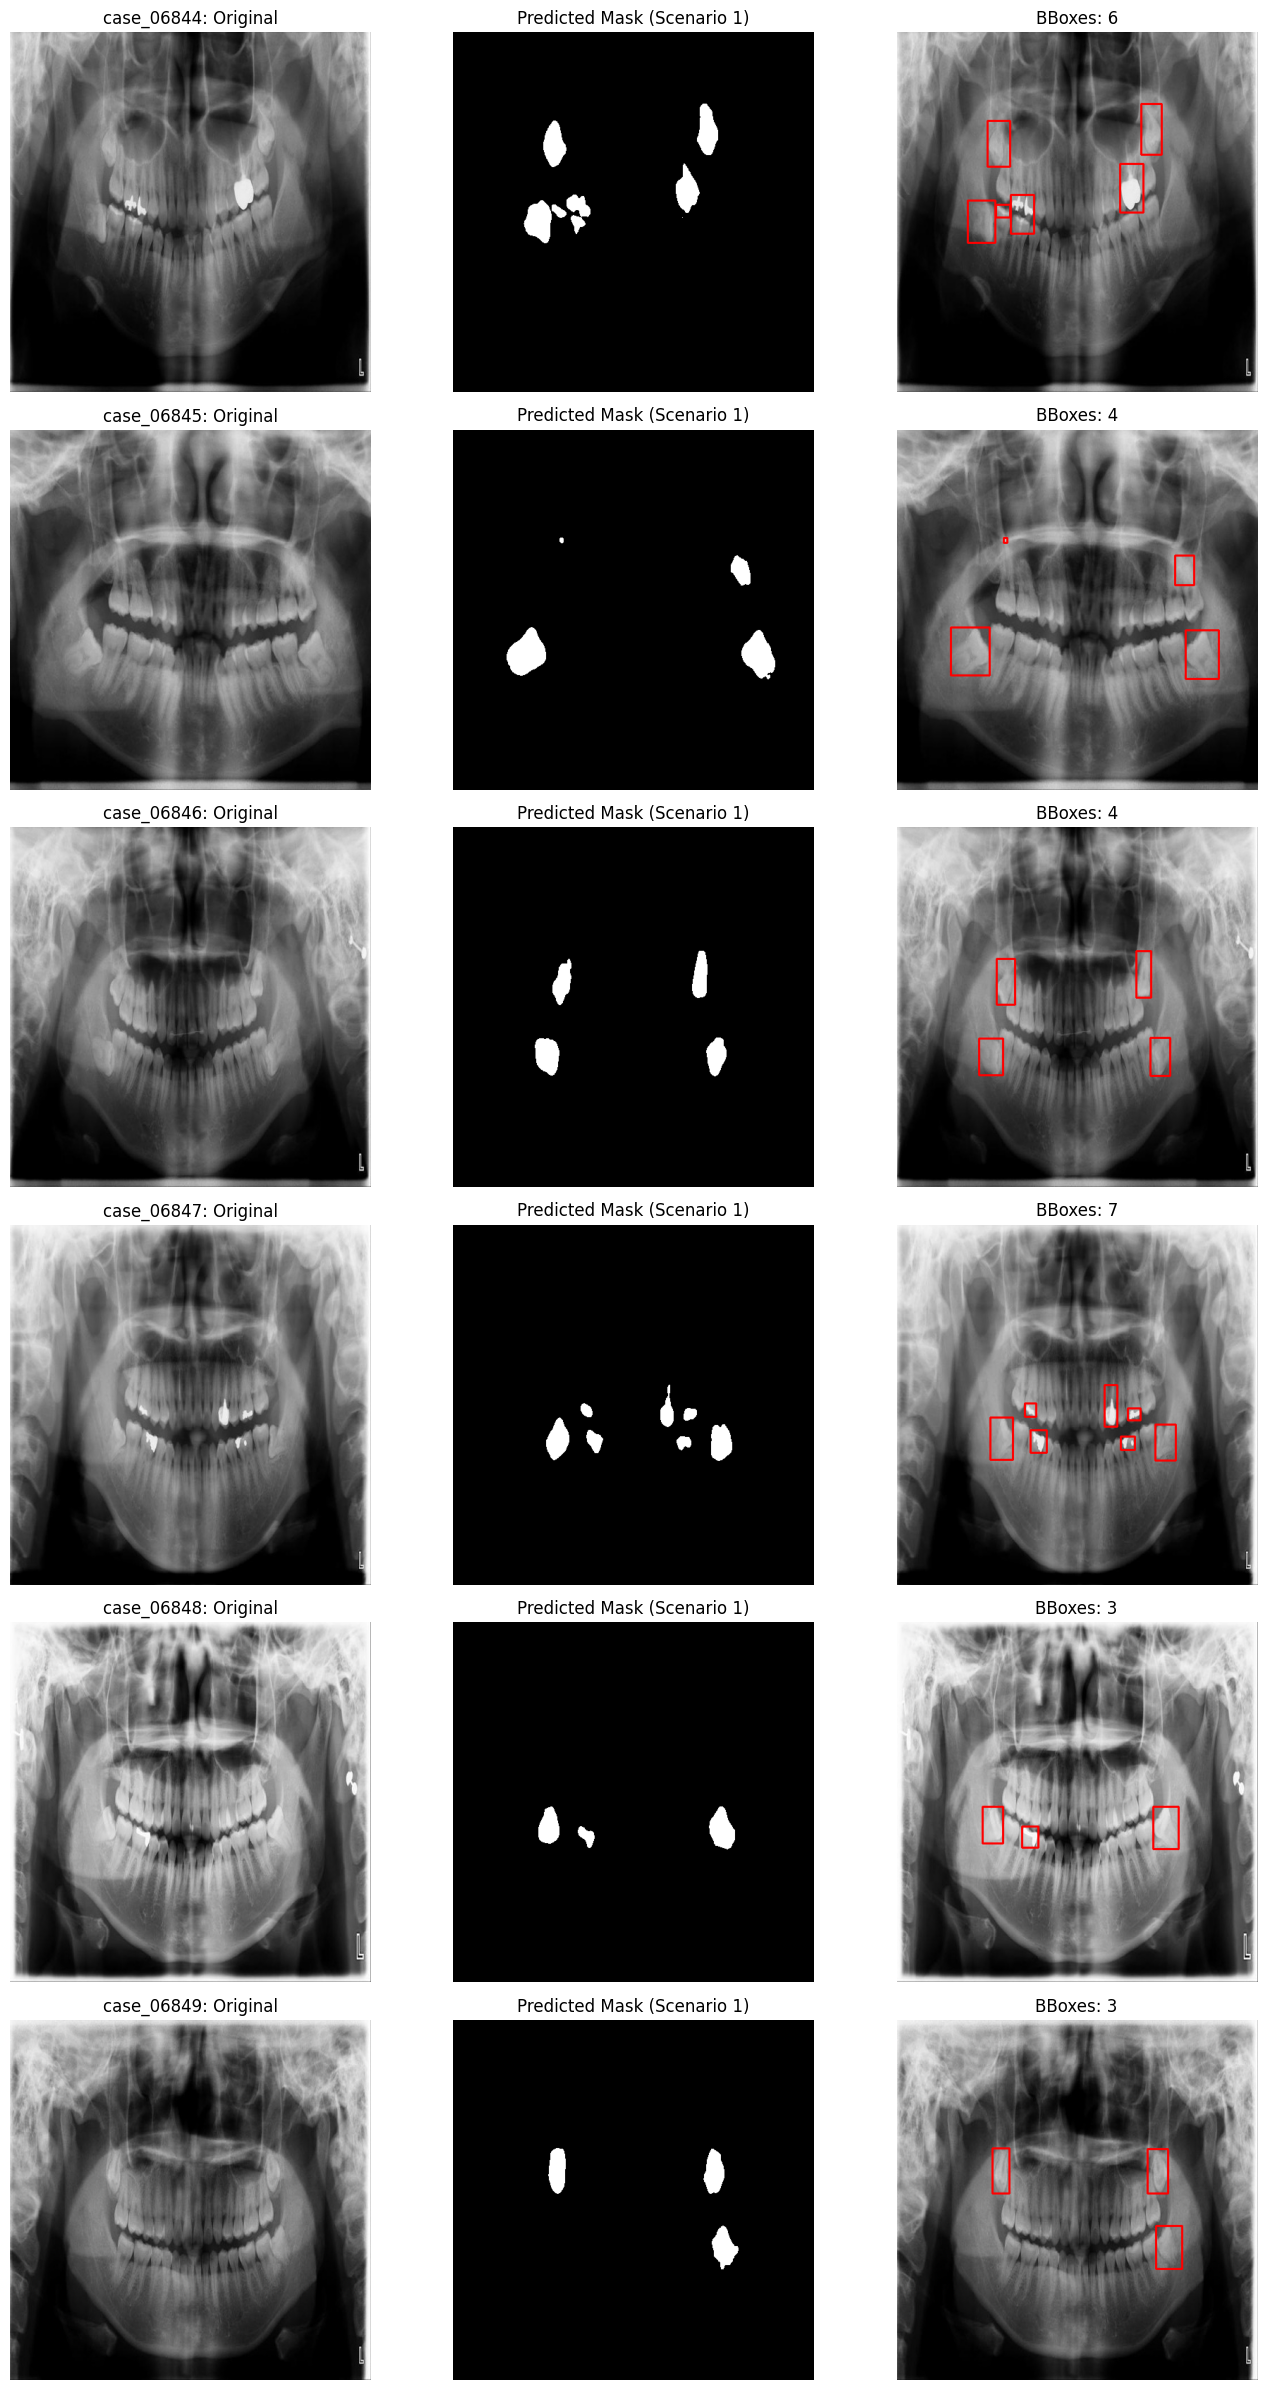

In [56]:
import matplotlib.pyplot as plt

def mask_to_bboxes(mask: np.ndarray, min_area: int = 10):
    if mask.ndim == 3:
        mask = cv2.cvtColor(mask, cv2.COLOR_BGR2GRAY)
    binary = (mask > 0).astype(np.uint8)

    n_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary, connectivity=8)
    boxes = []
    for label_idx in range(1, n_labels):
        x, y, w, h, area = stats[label_idx]
        if area >= min_area:
            boxes.append({'x1': int(x), 'y1': int(y), 'x2': int(x + w - 1), 'y2': int(y + h - 1), 'area': int(area)})
    return boxes

def draw_bboxes(image: np.ndarray, boxes, color=(0, 255, 0), thickness=2):
    out = image.copy()
    for b in boxes:
        cv2.rectangle(out, (b['x1'], b['y1']), (b['x2'], b['y2']), color, thickness)
    return out

with open(DATASET_DIR / 'filename_mapping.json', 'r', encoding='utf-8') as f:
    filename_mapping = json.load(f)

test_cases = [k for k, v in filename_mapping.items() if v['split'] == 'test']
bbox_results = {}

for case_id in tqdm(test_cases, desc='Extracting bboxes from scenario1 predictions'):
    pred_mask_path = SCENARIO1_PRED / f'{case_id}.png'
    if not pred_mask_path.exists():
        pred_mask_path = SCENARIO1_PRED / f'{case_id}_0000.png'
        if not pred_mask_path.exists():
            continue

    pred_mask = cv2.imread(str(pred_mask_path), cv2.IMREAD_UNCHANGED)
    boxes = mask_to_bboxes(pred_mask)
    bbox_results[case_id] = boxes

with open(SCENARIO1_BBOX_JSON, 'w', encoding='utf-8') as f:
    json.dump(bbox_results, f, indent=2)

print('Saved bbox results:', SCENARIO1_BBOX_JSON)

# Visualize a few test samples
sample_cases = test_cases[:6]
fig, axes = plt.subplots(len(sample_cases), 3, figsize=(14, 4 * max(1, len(sample_cases))))
if len(sample_cases) == 1:
    axes = np.expand_dims(axes, axis=0)

for row_idx, case_id in enumerate(sample_cases):
    pred_mask_path = SCENARIO1_PRED / f'{case_id}.png'
    if not pred_mask_path.exists():
        pred_mask_path = SCENARIO1_PRED / f'{case_id}_0000.png'

    original_img_path = Path(filename_mapping[case_id]['original_image_path'])
    image = cv2.imread(str(original_img_path), cv2.IMREAD_COLOR)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    pred_mask = cv2.imread(str(pred_mask_path), cv2.IMREAD_UNCHANGED)
    if pred_mask is None:
        pred_mask = np.zeros(image.shape[:2], dtype=np.uint8)

    boxes = bbox_results.get(case_id, [])
    image_bbox = draw_bboxes(image_rgb, boxes, color=(255, 0, 0), thickness=2)

    axes[row_idx, 0].imshow(image_rgb)
    axes[row_idx, 0].set_title(f'{case_id}: Original')
    axes[row_idx, 0].axis('off')

    axes[row_idx, 1].imshow(pred_mask, cmap='gray')
    axes[row_idx, 1].set_title('Predicted Mask (Scenario 1)')
    axes[row_idx, 1].axis('off')

    axes[row_idx, 2].imshow(image_bbox)
    axes[row_idx, 2].set_title(f'BBoxes: {len(boxes)}')
    axes[row_idx, 2].axis('off')

plt.tight_layout()
plt.show()

## 4) Scenario 2: Fine-Tuning

Run fine-tuning with dynamic GPU scaling using `-num_gpus {NUM_GPUS}`, dan pake baseline. weight initialization

The best checkpoint is stored under:
`$nnUNet_results/Dataset501_Dental/nnUNetTrainer__nnUNetPlans__2d/fold_0/checkpoint_best.pth`

In [57]:
# SCENARIO 2: Fine-Tuning via Weight Initialization
!nnUNetv2_train {DATASET_ID} 2d 0 -tr nnUNetTrainer_5epochs -pretrained_weights /kaggle/working/nnUNet_results/Dataset501_Dental/nnUNetTrainer_5epochs__nnUNetPlans__2d/fold_0/checkpoint_final.pth


############################
INFO: You are using the old nnU-Net default plans. We have updated our recommendations. Please consider using those instead! Read more here: https://github.com/MIC-DKFZ/nnUNet/blob/master/documentation/resenc_presets.md
############################

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
2026-04-19 06:37:03.536335: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776580623.559309   70924 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776580623.567010   70924 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin 

In [23]:
import shutil
import os

# Copy for Scenario 2
os.makedirs("/kaggle/working/nnUNet_results/Dataset501_Dental/nnUNetTrainer__nnUNetPlans__2d/fold_0", exist_ok=True)
shutil.copy("/kaggle/working/nnUNet_raw/Dataset501_Dental/dataset.json", "/kaggle/working/nnUNet_results/Dataset501_Dental/nnUNetTrainer__nnUNetPlans__2d/")

# Copy for Scenario 3
os.makedirs("/kaggle/working/nnUNet_results/Dataset501_Dental/nnUNetTrainerDiceFocal__nnUNetPlans__2d/fold_0", exist_ok=True)
shutil.copy("/kaggle/working/nnUNet_raw/Dataset501_Dental/dataset.json", "/kaggle/working/nnUNet_results/Dataset501_Dental/nnUNetTrainerDiceFocal__nnUNetPlans__2d/")

'/kaggle/working/nnUNet_results/Dataset501_Dental/nnUNetTrainerDiceFocal__nnUNetPlans__2d/dataset.json'

In [12]:
import shutil
import os

# Define the source and destination paths
src_json = "/kaggle/working/nnUNet_raw/Dataset501_Dental/dataset.json"
dst_dir = "/kaggle/working/nnUNet_results/Dataset501_Dental/nnUNetTrainer__nnUNetPlans__2d"

# Make sure the directory exists, then copy the file
os.makedirs(dst_dir, exist_ok=True)
shutil.copy(src_json, dst_dir)
print("dataset.json successfully copied to the results folder!")

dataset.json successfully copied to the results folder!


In [ ]:
print("--- Starting Scenario 2: Prediction ---")
!nnUNetv2_predict -i {IMAGES_TS} -o {SCENARIO2_PRED} -d {DATASET_ID} -c 2d -f 0 -tr nnUNetTrainer_5epochs -p nnUNetPlans -chk checkpoint_final.pth

print("--- Zipping Scenario 2 Output and Weights ---")
# Zips the prediction masks folder AND the specific .pth file
!zip -q -r /kaggle/working/Scenario2_Backup.zip {SCENARIO2_PRED} /kaggle/working/nnUNet_results/Dataset501_Dental/nnUNetTrainer_5epochs__nnUNetPlans__2d/fold_0/checkpoint_final.pth

print("✅ Scenario 2 finished and zipped as 'Scenario2_Backup.zip'!")

--- Starting Scenario 2: Prediction ---

#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
2026-04-19 06:57:40.950151: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776581860.973800   72833 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one

## 5) Scenario 3: Custom Loss (Dice + Focal)

In [60]:
import importlib
import nnunetv2

nnunet_pkg_root = Path(nnunetv2.__file__).resolve().parent
trainer_dir = nnunet_pkg_root / 'training' / 'nnUNetTrainer' / 'variants' / 'loss'
trainer_dir.mkdir(parents=True, exist_ok=True)

TRAINER_FILE = trainer_dir / 'nnUNetTrainerDiceFocal.py'
print('Custom trainer file path:', TRAINER_FILE)

Custom trainer file path: /usr/local/lib/python3.12/dist-packages/nnunetv2/training/nnUNetTrainer/variants/loss/nnUNetTrainerDiceFocal.py


In [42]:
# Ensure MONAI is available for DiceFocalLoss
!pip install -q monai

In [61]:
%%writefile {TRAINER_FILE}
import torch
import numpy as np
from nnunetv2.training.nnUNetTrainer.nnUNetTrainer import nnUNetTrainer
from monai.losses import DiceFocalLoss
from nnunetv2.training.loss.deep_supervision import DeepSupervisionWrapper

class nnUNetTrainerDiceFocal(nnUNetTrainer):
    """
    Custom trainer that replaces default loss with Dice + Focal,
    and restricts training to 5 epochs.
    """
    def __init__(self, plans: dict, configuration: str, fold: int, dataset_json: dict, device: torch.device = torch.device('cuda')):
        # CRITICAL: We pass exactly 5 explicit arguments. No *args, no **kwargs, and no unpack_dataset.
        super().__init__(plans, configuration, fold, dataset_json, device)
        
        # Override to limit training to 5 epochs for Kaggle constraints
        self.num_epochs = 5

    def _build_loss(self):
        # 1. Initialize MONAI's DiceFocalLoss as the base loss
        loss = DiceFocalLoss(
            include_background=False,
            to_onehot_y=True,
            softmax=True,
            batch=True,          # Calculates Dice over the whole batch, stabilizing gradients
            lambda_dice=1.0,     # Weight for Dice
            lambda_focal=1.0     # Weight for Focal
        )

        # 2. Wrap with Deep Supervision ONLY if enabled by the architecture
        if self.enable_deep_supervision:
            deep_supervision_scales = self._get_deep_supervision_scales()
            
            # Give each output a weight which decreases exponentially
            weights = np.array([1 / (2 ** i) for i in range(len(deep_supervision_scales))])
            
            # The lowest resolution is usually too coarse, so we zero it out
            if len(weights) > 1:
                weights[-1] = 0 
                
            # Normalize weights so they sum to 1
            weights = weights / weights.sum()
            
            # Wrap the base MONAI loss with nnU-Net's wrapper
            loss = DeepSupervisionWrapper(loss, weights)

        return loss

Overwriting /usr/local/lib/python3.12/dist-packages/nnunetv2/training/nnUNetTrainer/variants/loss/nnUNetTrainerDiceFocal.py


In [63]:
!nnUNetv2_train {DATASET_ID} 2d 0 -tr nnUNetTrainerDiceFocal -num_gpus {NUM_GPUS} -pretrained_weights /kaggle/working/nnUNet_results/Dataset501_Dental/nnUNetTrainer_5epochs__nnUNetPlans__2d/fold_0/checkpoint_final.pth
print("--- Starting Scenario 3: TRAIN ---")


############################
INFO: You are using the old nnU-Net default plans. We have updated our recommendations. Please consider using those instead! Read more here: https://github.com/MIC-DKFZ/nnUNet/blob/master/documentation/resenc_presets.md
############################

using port 35251
<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
2026-04-19 07:12:55.560618: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776582775.587897   74508 cuda_dnn.cc:8579] Unable to register cuDNN factory: A

In [64]:
SCENARIO3_OUT = BASE_DIR / 'outputs' / 'scenario3_custom_trainer'
SCENARIO3_PRED = SCENARIO3_OUT / 'pred_masks'
SCENARIO3_OUT.mkdir(parents=True, exist_ok=True)
SCENARIO3_PRED.mkdir(parents=True, exist_ok=True)

print("--- Starting Scenario 3: Prediction ---")
!nnUNetv2_predict -i {IMAGES_TS} -o {SCENARIO3_PRED} -d {DATASET_ID} -c 2d -f 0 -tr nnUNetTrainerDiceFocal -p nnUNetPlans -chk checkpoint_final.pth

print("--- Zipping Scenario 3 Output and Weights ---")
# Zips the prediction masks folder AND the specific custom trainer .pth file
!zip -q -r /kaggle/working/Scenario3_Backup.zip {SCENARIO3_PRED} /kaggle/working/nnUNet_results/Dataset501_Dental/nnUNetTrainerDiceFocal__nnUNetPlans__2d/fold_0/checkpoint_final.pth

--- Starting Scenario 3: Prediction ---

#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
2026-04-19 07:28:03.700946: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776583683.724917   77077 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one

## 6) Evaluation & Scenario Comparison

In [65]:
import pandas as pd

def dice_coefficient(gt: np.ndarray, pred: np.ndarray, eps: float = 1e-8):
    gt_bin = (gt > 0).astype(np.uint8)
    pred_bin = (pred > 0).astype(np.uint8)
    inter = (gt_bin & pred_bin).sum()
    denom = gt_bin.sum() + pred_bin.sum()
    return float((2.0 * inter + eps) / (denom + eps))

def union_bbox_from_mask(mask: np.ndarray):
    if mask.ndim == 3:
        mask = cv2.cvtColor(mask, cv2.COLOR_BGR2GRAY)
    ys, xs = np.where(mask > 0)
    if len(xs) == 0 or len(ys) == 0:
        return None
    return [int(xs.min()), int(ys.min()), int(xs.max()), int(ys.max())]

def bbox_iou(box_a, box_b, eps: float = 1e-8):
    if box_a is None and box_b is None:
        return 1.0
    if box_a is None or box_b is None:
        return 0.0

    ax1, ay1, ax2, ay2 = box_a
    bx1, by1, bx2, by2 = box_b

    inter_x1 = max(ax1, bx1)
    inter_y1 = max(ay1, by1)
    inter_x2 = min(ax2, bx2)
    inter_y2 = min(ay2, by2)

    inter_w = max(0, inter_x2 - inter_x1 + 1)
    inter_h = max(0, inter_y2 - inter_y1 + 1)
    inter_area = inter_w * inter_h

    area_a = max(0, ax2 - ax1 + 1) * max(0, ay2 - ay1 + 1)
    area_b = max(0, bx2 - bx1 + 1) * max(0, by2 - by1 + 1)

    union_area = area_a + area_b - inter_area
    return float((inter_area + eps) / (union_area + eps))

with open(DATASET_DIR / 'filename_mapping.json', 'r', encoding='utf-8') as f:
    filename_mapping = json.load(f)

test_cases = [k for k, v in filename_mapping.items() if v['split'] == 'test']

scenario_pred_dirs = {
    'scenario1_baseline': SCENARIO1_PRED,
    'scenario2_finetune': SCENARIO2_PRED,
    'scenario3_custom_loss': SCENARIO3_PRED
}

rows = []
for scenario, pred_dir in scenario_pred_dirs.items():
    case_dice = []
    case_iou = []

    for case_id in test_cases:
        gt_path = Path(filename_mapping[case_id]['original_mask_path'])
        gt = cv2.imread(str(gt_path), cv2.IMREAD_UNCHANGED)
        if gt is None:
            continue
        if gt.ndim == 3:
            gt = cv2.cvtColor(gt, cv2.COLOR_BGR2GRAY)

        pred_path = pred_dir / f'{case_id}.png'
        if not pred_path.exists():
            pred_path = pred_dir / f'{case_id}_0000.png'
        pred = cv2.imread(str(pred_path), cv2.IMREAD_UNCHANGED)
        if pred is None:
            pred = np.zeros_like(gt, dtype=np.uint8)
        if pred.ndim == 3:
            pred = cv2.cvtColor(pred, cv2.COLOR_BGR2GRAY)

        dice_val = dice_coefficient(gt, pred)
        iou_val = bbox_iou(union_bbox_from_mask(gt), union_bbox_from_mask(pred))

        case_dice.append(dice_val)
        case_iou.append(iou_val)

    rows.append({
        'scenario': scenario,
        'n_test_cases': len(case_dice),
        'dice_mean': float(np.mean(case_dice)) if case_dice else np.nan,
        'dice_std': float(np.std(case_dice)) if case_dice else np.nan,
        'bbox_iou_mean': float(np.mean(case_iou)) if case_iou else np.nan,
        'bbox_iou_std': float(np.std(case_iou)) if case_iou else np.nan
    })

report_df = pd.DataFrame(rows).sort_values('dice_mean', ascending=False).reset_index(drop=True)
report_csv = BASE_DIR / 'reports' / 'scenario_comparison.csv'
report_df.to_csv(report_csv, index=False)

print('Saved report:', report_csv)
display(report_df)

Saved report: /kaggle/working/reports/scenario_comparison.csv


,scenario,n_test_cases,dice_mean,dice_std,bbox_iou_mean,bbox_iou_std
0,scenario3_custom_loss,1345,0.700785,0.171541,0.757790,0.214232
1,scenario2_finetune,1345,0.682564,0.182978,0.733368,0.224542
2,scenario1_baseline,1345,0.657171,0.194164,0.713589,0.227411
